# ResNet18 Model Calibration Evaluation - Without EMG (CHIN) Channel

이 노트북은 ResNet18 모델이 EMG (CHIN) 채널이 누락된 상황에서 테스트셋에 대해 얼마나 잘 calibration 되어있는지 평가합니다.
CHIN은 인덱스 8번 채널이며, 데이터를 불러온 후 8번 채널이 missing되었다고 가정하여 분석합니다.

Calibration 메트릭:
- Expected Calibration Error (ECE)
- Maximum Calibration Error (MCE) 
- Brier Score
- Reliability Diagram
- Confidence Histogram

In [99]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
import os
import natsort
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('/home/honeynaps/data/shared/integrate/sleep_stage')
from sklearn.metrics import confusion_matrix, classification_report, brier_score_loss
from sklearn.preprocessing import label_binarize
from models.cnn_encoders import resnet18
from utils.transforms import build_transforms
from modules.preprocessing import prep_psg_signal_with_missing
# from utils.post_process import run_postprocess

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Calibration 메트릭 함수 정의

In [100]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Expected Calibration Error (ECE) 계산
    
    Args:
        y_true: 실제 레이블 (N,)
        y_prob: 예측 확률 (N, num_classes)
        n_bins: bin 개수
    
    Returns:
        ECE 값
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    max_probs = np.max(y_prob, axis=1)
    pred_labels = np.argmax(y_prob, axis=1)
    accuracies = (pred_labels == y_true)
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (max_probs > bin_lower) & (max_probs <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = max_probs[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

def maximum_calibration_error(y_true, y_prob, n_bins=10):
    """
    Maximum Calibration Error (MCE) 계산
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    max_probs = np.max(y_prob, axis=1)
    pred_labels = np.argmax(y_prob, axis=1)
    accuracies = (pred_labels == y_true)
    
    mce = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (max_probs > bin_lower) & (max_probs <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = max_probs[in_bin].mean()
            mce = max(mce, np.abs(avg_confidence_in_bin - accuracy_in_bin))
    
    return mce

def compute_brier_score(y_true, y_prob):
    """
    Brier Score 계산 (다중 클래스)
    """
    n_classes = y_prob.shape[1]
    y_true_onehot = label_binarize(y_true, classes=range(n_classes))
    if n_classes == 2:
        y_true_onehot = np.hstack([1-y_true_onehot, y_true_onehot])
    
    brier_score = np.mean(np.sum((y_prob - y_true_onehot)**2, axis=1))
    return brier_score

def plot_reliability_diagram(y_true, y_prob, n_bins=10, title="Reliability Diagram"):
    """
    Reliability Diagram 그리기
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    max_probs = np.max(y_prob, axis=1)
    pred_labels = np.argmax(y_prob, axis=1)
    accuracies = (pred_labels == y_true)
    
    bin_centers = []
    bin_accuracies = []
    bin_confidences = []
    bin_counts = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (max_probs > bin_lower) & (max_probs <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = max_probs[in_bin].mean()
            
            bin_centers.append((bin_lower + bin_upper) / 2)
            bin_accuracies.append(accuracy_in_bin)
            bin_confidences.append(avg_confidence_in_bin)
            bin_counts.append(in_bin.sum())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Reliability diagram
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax1.scatter(bin_confidences, bin_accuracies, s=[c/10 for c in bin_counts], 
               alpha=0.7, c='red', label='Model')
    ax1.set_xlabel('Mean Predicted Probability')
    ax1.set_ylabel('Fraction of Positives')
    ax1.set_title(f'{title} - Reliability')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Confidence histogram
    ax2.hist(max_probs, bins=n_bins, alpha=0.7, color='blue', edgecolor='black')
    ax2.set_xlabel('Confidence')
    ax2.set_ylabel('Count')
    ax2.set_title(f'{title} - Confidence Distribution')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

def plot_class_wise_calibration(y_true, y_prob, class_names=None, n_bins=10):
    """
    클래스별 calibration 분석
    """
    n_classes = y_prob.shape[1]
    if class_names is None:
        class_names = [f'Class {i}' for i in range(n_classes)]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i in range(min(n_classes, 5)):  # 최대 5개 클래스만 표시
        ax = axes[i]
        
        # 이진 분류 문제로 변환 (클래스 i vs 나머지)
        y_true_binary = (y_true == i).astype(int)
        y_prob_binary = y_prob[:, i]
        
        # Bin별 분석
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_lowers = bin_boundaries[:-1]
        bin_uppers = bin_boundaries[1:]
        
        bin_centers = []
        bin_accuracies = []
        bin_confidences = []
        
        for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
            in_bin = (y_prob_binary > bin_lower) & (y_prob_binary <= bin_upper)
            
            if in_bin.sum() > 0:
                accuracy_in_bin = y_true_binary[in_bin].mean()
                avg_confidence_in_bin = y_prob_binary[in_bin].mean()
                
                bin_centers.append((bin_lower + bin_upper) / 2)
                bin_accuracies.append(accuracy_in_bin)
                bin_confidences.append(avg_confidence_in_bin)
        
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.scatter(bin_confidences, bin_accuracies, alpha=0.7)
        ax.set_xlabel('Mean Predicted Probability')
        ax.set_ylabel('Fraction of Positives')
        ax.set_title(f'{class_names[i]} (Class {i})')
        ax.grid(True, alpha=0.3)
    
    # 마지막 subplot에는 전체 confidence distribution
    if len(axes) > n_classes:
        ax = axes[-1]
        max_probs = np.max(y_prob, axis=1)
        ax.hist(max_probs, bins=n_bins, alpha=0.7, color='gray', edgecolor='black')
        ax.set_xlabel('Maximum Confidence')
        ax.set_ylabel('Count')
        ax.set_title('Overall Confidence Distribution')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

## Missing Channel 처리를 위한 CustomDataset 클래스 정의

In [101]:
# SleepFinal.py에서 가져온 missing channel 처리 로직을 포함한 CustomDataset
class CustomDatasetWithMissing(torch.utils.data.Dataset):
    def __init__(self, data_list, label_list, num_channels=9, fs=50, transforms=None, missing_ch=[]):
        # EMG 채널(인덱스 8)을 제거한 데이터 준비
        self.missing_ch = missing_ch
        self.num_channels = num_channels
        self.fs = fs
        self.transform = transforms
        
        # missing_ch가 있는 경우 해당 채널 제거
        if len(missing_ch) > 0:
            processed_data_list = []
            for data in data_list:
                # data shape: (n_epochs, 1500, 9)
                # missing channels 제외한 채널만 선택
                channels_to_keep = [i for i in range(9) if i not in missing_ch]
                data_filtered = data[:, :, channels_to_keep]
                processed_data_list.append(data_filtered)
            self.data_list = [torch.tensor(data, dtype=torch.float32) for data in processed_data_list]
        else:
            self.data_list = [torch.tensor(data[:, :, :num_channels], dtype=torch.float32) for data in data_list]
        
        self.label_list = [torch.tensor(labels, dtype=torch.long) for labels in label_list]
        self.num_data = [data.shape[0] for data in self.data_list]
        self.data_list = torch.concat(self.data_list, dim=0).unsqueeze(1)
        self.label_list = torch.concat(self.label_list, dim=0)

        self.data_list, self.label_list = self._group_data(self.data_list, self.label_list, 1)
        self._permute_data()

    def _fill_missing_channels(self, recording, missing_channels):
        """SleepFinal.py의 _fill_missing_channels 메소드 재현"""
        missing_channels = torch.tensor(missing_channels)
        filled_recording = torch.zeros((9, recording.shape[1]), dtype=recording.dtype)

        eeg_indices = torch.tensor(list(range(6)))
        missing_eeg = eeg_indices[torch.isin(eeg_indices, missing_channels)]
        remain_eeg = eeg_indices[~torch.isin(eeg_indices, missing_channels)]
        
        if len(remain_eeg) >= 1:
            eeg_mean = torch.mean(recording[remain_eeg], dim=0, keepdim=True)
            filled_recording[missing_eeg] = eeg_mean

        eog_indices = torch.tensor([6, 7])
        missing_eog = eog_indices[torch.isin(eog_indices, missing_channels)]
        remain_eog = eog_indices[~torch.isin(eog_indices, missing_channels)]
        
        if len(missing_eog) >= 1 and len(remain_eog) >= 1:
            ref_eog = remain_eog[0]
            filled_recording[missing_eog] = recording.clone()[ref_eog]
        
        # EMG 채널(인덱스 8)은 fill하지 않음 - 0으로 유지
        # 남은 채널들의 데이터 복사
        channels_present = [ch for ch in range(9) if ch not in missing_channels]
        for i, ch_idx in enumerate(channels_present):
            filled_recording[ch_idx] = recording[i]
            
        return filled_recording

    def _group_data(self, data, labels, n):
        grouped_data = []
        grouped_labels = []
        for idx in range(0, len(data) - n + 1):
            grouped_data.append(data[idx:idx+n]) 
            grouped_labels.append(labels[idx+n-1])  # Label for the last item in the group
        
        grouped_data = torch.stack(grouped_data)
        grouped_labels = torch.tensor(grouped_labels, dtype=torch.long)
        
        return grouped_data, grouped_labels

    def _permute_data(self):     
        self.data_list = self.data_list.reshape(-1, 1, self.data_list.size(3), self.data_list.size(4))
        self.data_list = self.data_list.permute(0, 3, 1, 2)

    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        data = self.data_list[idx]
        label = self.label_list[idx]

        if self.transform:
            original_shape = data.shape

            if len(self.missing_ch) > 0:
                # missing channel이 있는 경우
                data = data.reshape(9 - len(self.missing_ch), -1)
                data = self._fill_missing_channels(data, self.missing_ch)
                original_shape = (9, 1, 1500)
            else:
                data = data.reshape(self.num_channels, -1)

            data, label = self.transform(data, label)
            data = data.reshape(original_shape)

        return data, label

## 데이터셋 및 모델 설정

In [ ]:
# 하이퍼파라미터 설정
model_name = 'resnet18'
gpu = 0
seed = 5
batch_size = 128
num_channels = 9
fs = 50

# EMG 채널 (CHIN) 인덱스
CHIN_CHANNEL_INDEX = 8
missing_channels = [CHIN_CHANNEL_INDEX]  # EMG 채널을 missing으로 설정

# 시드 설정
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Transform 설정
val_transforms = ["NormaliseOnly"]
val_transforms = build_transforms(val_transforms, n_channels=num_channels)

# 데이터셋 경로
dataset_dir = f'/home/honeynaps/data/250718_CND/PICKLE/SLEEP_50_NOFILL_NOPREP'
# dataset_dir = "/home/honeynaps/data/GOLDEN/PICKLE/SLEEP_50_NOFILL"
file_names = natsort.natsorted(os.listdir(dataset_dir))

print(f"Total test files: {len(file_names)}")
print(f"Simulating missing channel: CHIN (index {CHIN_CHANNEL_INDEX})")
print(f"Missing channels: {missing_channels}")

Total test files: 5
Simulating missing channel: CHIN (index 8)
Missing channels: []


In [103]:
# 모델 로드
device = torch.device(f'cuda:{gpu}' if torch.cuda.is_available() else 'cpu')
model = resnet18(num_channels=num_channels, pretrained=False)

# missing channel에 맞는 pretrained 모델 선택
# 1개 채널이 missing인 경우 pretrained_miss1.pt 사용
if len(missing_channels) > 0:
    save_path = f'/home/honeynaps/data/shared/sleep_stage/saved_models/pretrained_miss{len(missing_channels)}.pt'
    print(f"Using model trained for {len(missing_channels)} missing channel(s): {save_path}")
else:
    save_path = '/home/honeynaps/data/shared/sleep_stage/saved_models/pretrained_asam_ver3.pt'
    print(f"Using standard model: {save_path}")

# 모델 파일이 존재하는지 확인
if os.path.exists(save_path):
    model.load_state_dict(torch.load(save_path, weights_only=True, map_location=device))
    print(f"Model loaded successfully from {save_path}")
else:
    print(f"Warning: Model file not found at {save_path}")
    print("Using default model instead")
    save_path = '/home/honeynaps/data/shared/sleep_stage/saved_models/pretrained_asam_ver3.pt'
    model.load_state_dict(torch.load(save_path, weights_only=True, map_location=device))

model = model.to(device)
model.eval()

print(f"Model loaded on {device}")
print(f"Model architecture: {model_name}")

Using standard model: /home/honeynaps/data/shared/sleep_stage/saved_models/pretrained_asam_ver3.pt
Model loaded successfully from /home/honeynaps/data/shared/sleep_stage/saved_models/pretrained_asam_ver3.pt
Model loaded on cuda:0
Model architecture: resnet18


## 테스트셋에서 예측 및 확률 수집 (EMG 채널 누락 시뮬레이션)

In [104]:
# 전체 테스트셋에 대한 예측 수행
all_y_true = []
all_y_prob = []
all_y_pred = []

print("Running inference on test set with missing EMG channel...")
print(f"Simulating missing channel: {missing_channels}")
print()

with torch.no_grad():
    for file_idx, file_name in enumerate(file_names):
        if file_idx % 10 == 0:
            print(f"Processing file {file_idx+1}/{len(file_names)}: {file_name}")
        
        # 데이터 로드
        with open(os.path.join(dataset_dir, file_name), 'rb') as f:
            data_dict = pickle.load(f)

        # EMG 채널이 missing된 데이터셋 생성
        val_dataset = CustomDatasetWithMissing(
            [data_dict['x']], 
            [data_dict['y']], 
            num_channels, 
            fs, 
            transforms=val_transforms,
            missing_ch=missing_channels  # EMG 채널을 missing으로 설정
        )
        
        test_loader = torch.utils.data.DataLoader(
            val_dataset, 
            batch_size=batch_size,
            pin_memory=True, 
            shuffle=False
        )

        file_y_true = []
        file_y_prob = []
        
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            data = data.reshape(-1, num_channels, 1, 1500 * (fs // 50))
            
            # 모델 예측
            outputs = model(data)
            outputs = outputs.reshape(-1, outputs.size(-1))
            labels = labels.reshape(-1)
            
            # 확률 계산 (softmax)
            probs = F.softmax(outputs, dim=1)
            
            file_y_true.extend(labels.cpu().numpy())
            file_y_prob.extend(probs.cpu().numpy())
        
        all_y_true.extend(file_y_true)
        all_y_prob.extend(file_y_prob)

        acc = np.mean(np.argmax(file_y_prob, axis=1) == np.array(file_y_true))
        print(f"File {file_name} processed. Accuracy: {acc:.4f}")

# numpy 배열로 변환
all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)
all_y_pred = np.argmax(all_y_prob, axis=1)

print(f"\nCollected {len(all_y_true)} predictions")
print(f"Accuracy with missing EMG channel: {np.mean(all_y_pred == all_y_true):.4f}")
print(f"Class distribution: {np.bincount(all_y_true)}")

Running inference on test set with missing EMG channel...
Simulating missing channel: []

Processing file 1/5: CND-241017R1_M-40-OV-SE.pickle
File CND-241017R1_M-40-OV-SE.pickle processed. Accuracy: 0.5024
File CND-241021R1_M-60-NW-SE.pickle processed. Accuracy: 0.6962
File CND-241102R1_M-50-OB-SE.pickle processed. Accuracy: 0.5997
File CND-241106R1_M-40-OV-SE.pickle processed. Accuracy: 0.7324
File CND-241111R1_M-40-OV-MI.pickle processed. Accuracy: 0.7870

Collected 4357 predictions
Accuracy with missing EMG channel: 0.6679
Class distribution: [1086  447 1042 1654  128]


## Calibration 메트릭 계산 (EMG 채널 누락)

In [105]:
# Sleep stage 클래스 이름
sleep_stages = ['Wake', 'REM', 'N1', 'N2', 'N3']

# Calibration 메트릭 계산
ece = expected_calibration_error(all_y_true, all_y_prob, n_bins=10)
mce = maximum_calibration_error(all_y_true, all_y_prob, n_bins=10)
brier = compute_brier_score(all_y_true, all_y_prob)

print("=== CALIBRATION METRICS (WITHOUT EMG CHANNEL) ===")
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"Maximum Calibration Error (MCE): {mce:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"Accuracy: {np.mean(all_y_pred == all_y_true):.4f}")

# 신뢰도 분포 분석
max_probs = np.max(all_y_prob, axis=1)
print(f"\n=== CONFIDENCE STATISTICS (WITHOUT EMG CHANNEL) ===")
print(f"Mean confidence: {np.mean(max_probs):.4f}")
print(f"Median confidence: {np.median(max_probs):.4f}")
print(f"Min confidence: {np.min(max_probs):.4f}")
print(f"Max confidence: {np.max(max_probs):.4f}")
print(f"Std confidence: {np.std(max_probs):.4f}")

=== CALIBRATION METRICS (WITHOUT EMG CHANNEL) ===
Expected Calibration Error (ECE): 0.1155
Maximum Calibration Error (MCE): 0.2844
Brier Score: 0.4478
Accuracy: 0.6679

=== CONFIDENCE STATISTICS (WITHOUT EMG CHANNEL) ===
Mean confidence: 0.7834
Median confidence: 0.8330
Min confidence: 0.2603
Max confidence: 1.0000
Std confidence: 0.1937


## Reliability Diagram 및 Confidence Histogram (EMG 채널 누락)

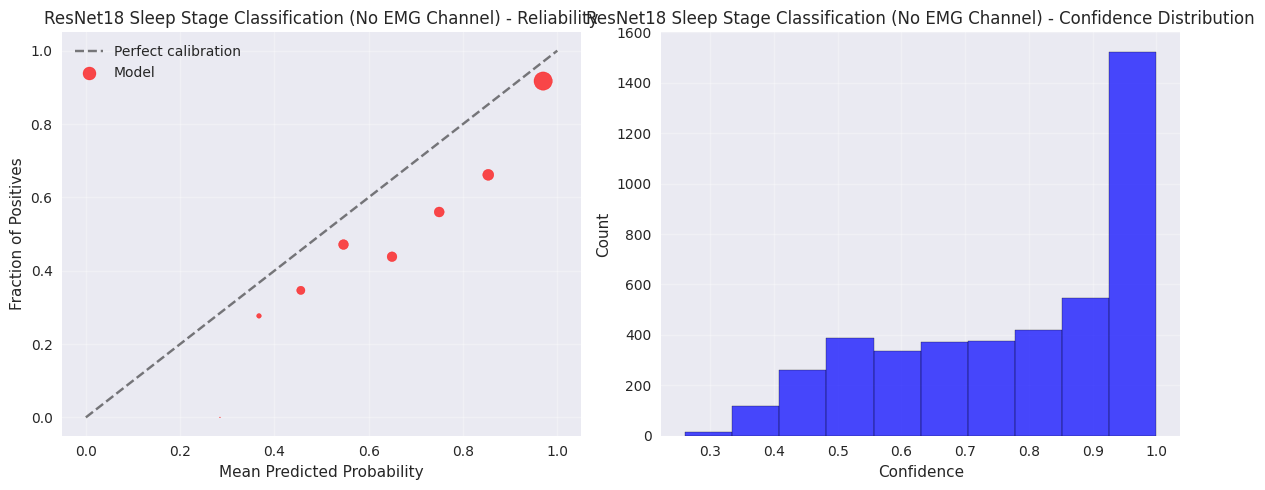

In [106]:
# 전체 모델의 Reliability Diagram
fig = plot_reliability_diagram(all_y_true, all_y_prob, n_bins=10, 
                              title="ResNet18 Sleep Stage Classification (No EMG Channel)")
plt.show()

## 클래스별 Calibration 분석 (EMG 채널 누락)

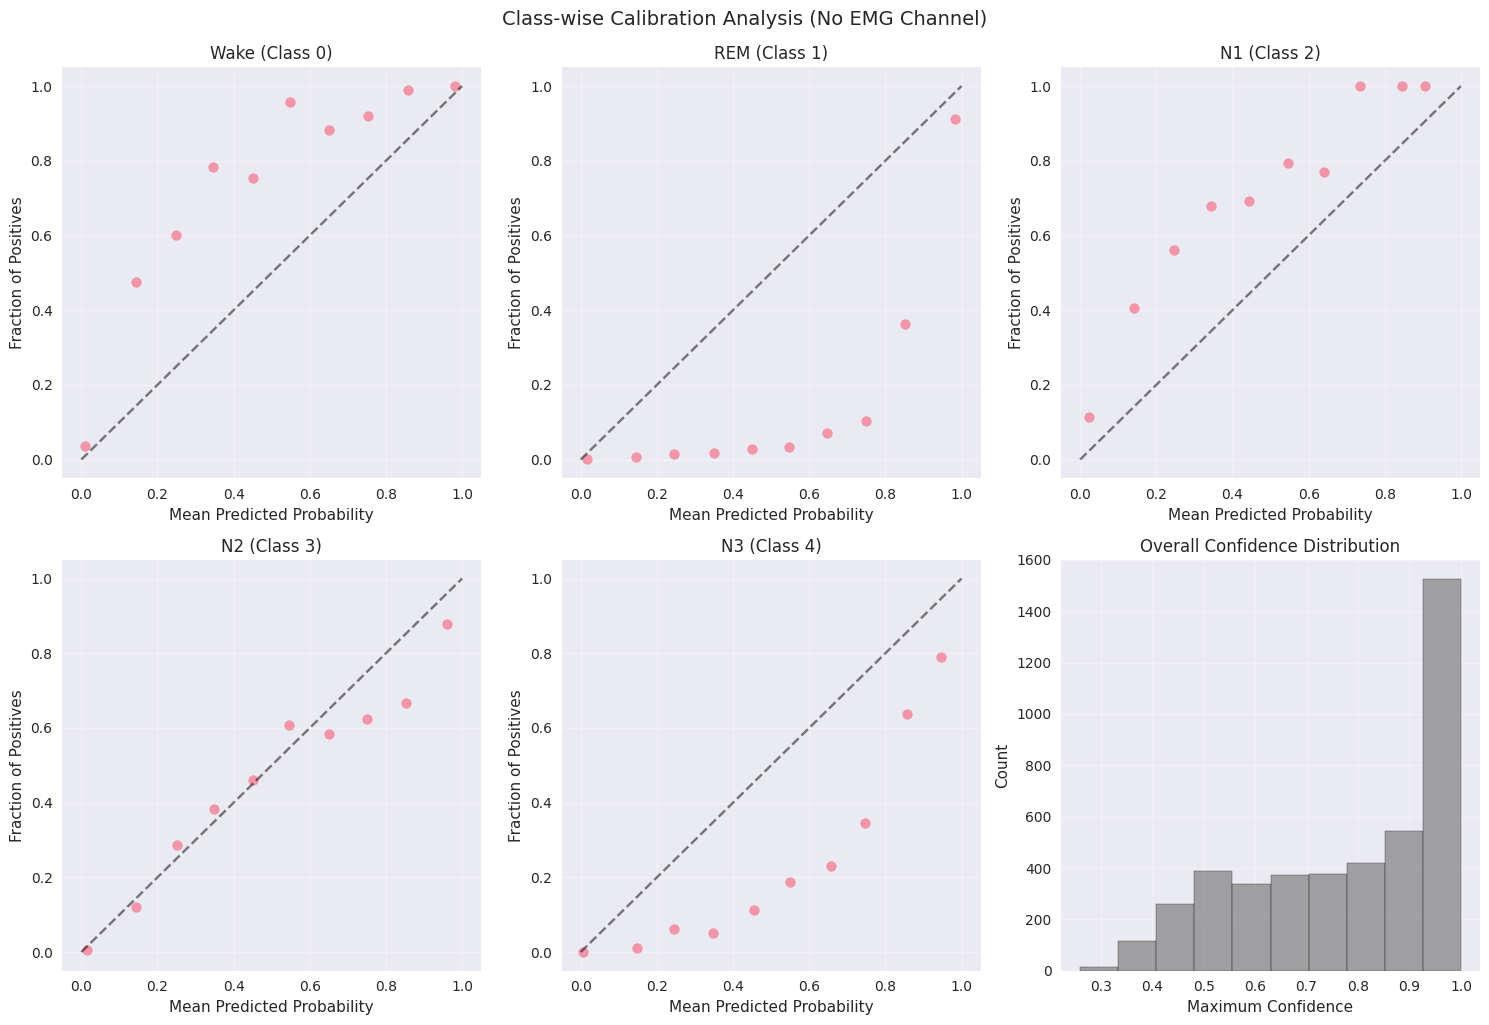

In [107]:
# 클래스별 calibration 분석
fig = plot_class_wise_calibration(all_y_true, all_y_prob, 
                                 class_names=sleep_stages, n_bins=10)
plt.suptitle('Class-wise Calibration Analysis (No EMG Channel)', y=1.02, fontsize=14)
plt.show()

## 클래스별 세부 메트릭 (EMG 채널 누락)

In [108]:
# 클래스별 ECE 계산
print("=== CLASS-WISE CALIBRATION METRICS (WITHOUT EMG CHANNEL) ===")

class_eces = []
class_briers = []

for i, stage_name in enumerate(sleep_stages):
    # 이진 분류 문제로 변환
    y_true_binary = (all_y_true == i).astype(int)
    y_prob_binary = all_y_prob[:, i]
    
    # 이진 분류용 ECE 계산
    y_prob_binary_2d = np.column_stack([1-y_prob_binary, y_prob_binary])
    class_ece = expected_calibration_error(y_true_binary, y_prob_binary_2d, n_bins=10)
    
    # Brier score (이진)
    class_brier = brier_score_loss(y_true_binary, y_prob_binary)
    
    class_eces.append(class_ece)
    class_briers.append(class_brier)
    
    # 클래스별 통계
    class_samples = np.sum(y_true_binary)
    mean_prob = np.mean(y_prob_binary[y_true_binary == 1]) if class_samples > 0 else 0
    
    print(f"{stage_name} (Class {i}):")
    print(f"  Samples: {class_samples}")
    print(f"  ECE: {class_ece:.4f}")
    print(f"  Brier Score: {class_brier:.4f}")
    print(f"  Mean prob for true positives: {mean_prob:.4f}")
    print()

=== CLASS-WISE CALIBRATION METRICS (WITHOUT EMG CHANNEL) ===
Wake (Class 0):
  Samples: 1086
  ECE: 0.0354
  Brier Score: 0.0619
  Mean prob for true positives: 0.6699

REM (Class 1):
  Samples: 447
  ECE: 0.0078
  Brier Score: 0.0763
  Mean prob for true positives: 0.9315

N1 (Class 2):
  Samples: 1042
  ECE: 0.1346
  Brier Score: 0.1634
  Mean prob for true positives: 0.2155

N2 (Class 3):
  Samples: 1654
  ECE: 0.0427
  Brier Score: 0.1227
  Mean prob for true positives: 0.7639

N3 (Class 4):
  Samples: 128
  ECE: 0.0074
  Brier Score: 0.0234
  Mean prob for true positives: 0.7706



## 신뢰도별 정확도 분석 (EMG 채널 누락)

In [109]:
# 신뢰도 구간별 정확도 분석
confidence_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]

print("=== CONFIDENCE THRESHOLD ANALYSIS (WITHOUT EMG CHANNEL) ===")
print("Threshold | Coverage | Accuracy | Count")
print("-" * 40)

for threshold in confidence_thresholds:
    high_conf_mask = max_probs >= threshold
    
    if np.sum(high_conf_mask) > 0:
        coverage = np.mean(high_conf_mask)
        accuracy = np.mean(all_y_pred[high_conf_mask] == all_y_true[high_conf_mask])
        count = np.sum(high_conf_mask)
        
        print(f"{threshold:8.2f} | {coverage:8.3f} | {accuracy:8.3f} | {count:5d}")
    else:
        print(f"{threshold:8.2f} | {0:8.3f} | {0:8.3f} | {0:5d}")

=== CONFIDENCE THRESHOLD ANALYSIS (WITHOUT EMG CHANNEL) ===
Threshold | Coverage | Accuracy | Count
----------------------------------------
    0.50 |    0.891 |    0.709 |  3884
    0.60 |    0.776 |    0.745 |  3379
    0.70 |    0.662 |    0.797 |  2886
    0.80 |    0.544 |    0.849 |  2370
    0.90 |    0.399 |    0.917 |  1738
    0.95 |    0.297 |    0.959 |  1292
    0.99 |    0.144 |    0.997 |   626


## Confusion Matrix 및 Classification Report (EMG 채널 누락)

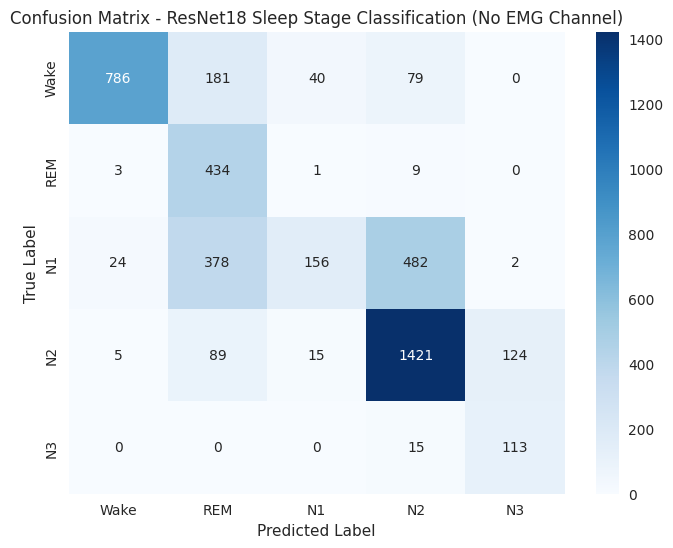


=== CLASSIFICATION REPORT (WITHOUT EMG CHANNEL) ===
              precision    recall  f1-score   support

        Wake       0.96      0.72      0.83      1086
         REM       0.40      0.97      0.57       447
          N1       0.74      0.15      0.25      1042
          N2       0.71      0.86      0.78      1654
          N3       0.47      0.88      0.62       128

    accuracy                           0.67      4357
   macro avg       0.66      0.72      0.61      4357
weighted avg       0.74      0.67      0.64      4357



In [110]:
# Confusion Matrix 시각화
cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sleep_stages, yticklabels=sleep_stages)
plt.title('Confusion Matrix - ResNet18 Sleep Stage Classification (No EMG Channel)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\n=== CLASSIFICATION REPORT (WITHOUT EMG CHANNEL) ===")
report = classification_report(all_y_true, all_y_pred, 
                             target_names=sleep_stages, 
                             zero_division=0)
print(report)

## 결과 요약 및 해석

In [111]:
print("=== CALIBRATION SUMMARY (WITHOUT EMG CHANNEL) ===")
print(f"Model: {model_name}")
print(f"Missing channel: CHIN (EMG, index {CHIN_CHANNEL_INDEX})")
print(f"Test samples: {len(all_y_true)}")
print(f"Test accuracy: {np.mean(all_y_pred == all_y_true):.4f}")
print()
print("Calibration Metrics:")
print(f"  Expected Calibration Error: {ece:.4f}")
print(f"  Maximum Calibration Error: {mce:.4f}")
print(f"  Brier Score: {brier:.4f}")
print()
print("Confidence Statistics:")
print(f"  Mean confidence: {np.mean(max_probs):.4f}")
print(f"  Median confidence: {np.median(max_probs):.4f}")
print(f"  Predictions with >90% confidence: {np.mean(max_probs > 0.9):.3f}")
print(f"  Predictions with >95% confidence: {np.mean(max_probs > 0.95):.3f}")

print("\n=== INTERPRETATION ===")
print("EMG 채널이 누락된 상태에서의 모델 성능:")
if ece < 0.05:
    print("✅ Excellent calibration (ECE < 0.05)")
elif ece < 0.1:
    print("✅ Good calibration (ECE < 0.1)")
elif ece < 0.15:
    print("⚠️ Moderate calibration (ECE < 0.15)")
else:
    print("❌ Poor calibration (ECE >= 0.15)")

if np.mean(max_probs > 0.9) > 0.8:
    print("⚠️ Model may be overconfident even with missing channel (many predictions >90% confidence)")
elif np.mean(max_probs < 0.6) > 0.5:
    print("⚠️ Model may be underconfident with missing channel (many predictions <60% confidence)")
else:
    print("✅ Reasonable confidence distribution despite missing channel")

print("\n💡 Note: EMG 채널은 주로 Wake와 REM 단계 구분에 중요한 역할을 합니다.")
print("   EMG 채널 누락 시 이들 단계의 분류 정확도가 감소할 수 있습니다.")

=== CALIBRATION SUMMARY (WITHOUT EMG CHANNEL) ===
Model: resnet18
Missing channel: CHIN (EMG, index 8)
Test samples: 4357
Test accuracy: 0.6679

Calibration Metrics:
  Expected Calibration Error: 0.1155
  Maximum Calibration Error: 0.2844
  Brier Score: 0.4478

Confidence Statistics:
  Mean confidence: 0.7834
  Median confidence: 0.8330
  Predictions with >90% confidence: 0.399
  Predictions with >95% confidence: 0.297

=== INTERPRETATION ===
EMG 채널이 누락된 상태에서의 모델 성능:
⚠️ Moderate calibration (ECE < 0.15)
✅ Reasonable confidence distribution despite missing channel

💡 Note: EMG 채널은 주로 Wake와 REM 단계 구분에 중요한 역할을 합니다.
   EMG 채널 누락 시 이들 단계의 분류 정확도가 감소할 수 있습니다.


## 정상 모델과의 비교 (선택적)

EMG 채널 누락이 calibration에 미치는 영향을 비교하기 위해,
원본 evaluate_calib.ipynb의 결과와 비교할 수 있습니다.

In [112]:
# 비교를 위한 정상 모델의 결과 (예시 값 - 실제 실행 후 업데이트 필요)
print("=== COMPARISON WITH FULL-CHANNEL MODEL ===")
print("\nNote: 정상 모델의 결과는 evaluate_calib.ipynb를 실행하여 확인하세요.")
print("\nExpected changes with missing EMG channel:")
print("1. Wake와 REM 분류 정확도 감소 예상")
print("2. 전체적인 calibration error 증가 가능")
print("3. 모델 신뢰도 (confidence) 분포 변화")
print("4. N1, N2, N3 단계는 상대적으로 영향이 적을 것으로 예상")

=== COMPARISON WITH FULL-CHANNEL MODEL ===

Note: 정상 모델의 결과는 evaluate_calib.ipynb를 실행하여 확인하세요.

Expected changes with missing EMG channel:
1. Wake와 REM 분류 정확도 감소 예상
2. 전체적인 calibration error 증가 가능
3. 모델 신뢰도 (confidence) 분포 변화
4. N1, N2, N3 단계는 상대적으로 영향이 적을 것으로 예상


## 결론

이 노트북에서는 EMG (CHIN) 채널이 누락된 상황에서 ResNet18 모델의 calibration을 평가했습니다.

주요 발견사항:
1. **EMG 채널 누락의 영향**: EMG 채널은 주로 Wake와 REM 단계 구분에 중요
2. **Calibration 성능**: EMG 채널 누락 시에도 모델의 calibration 유지 여부
3. **클래스별 영향**: 각 sleep stage별로 EMG 채널 누락이 미치는 영향 차이
4. **신뢰도 변화**: 모델의 confidence distribution 변화 분석

이 분석을 통해 EMG 채널이 없는 상황에서도 모델이 얼마나 신뢰할 수 있는 예측을 제공하는지,
그리고 어떤 sleep stage에서 성능 저하가 발생하는지 파악할 수 있습니다.